# Pipeline Nhận Diện Biển Số Xe

Notebook này trình bày từng bước trong pipeline nhận diện biển số xe,
theo đúng thứ tự được mô tả trong `README.md`.

```
Ảnh xe → YOLO phát hiện → Crop biển số → Grayscale → CLAHE
→ Gaussian Blur → Adaptive Threshold → Morphology
→ Segment ký tự → HOG → kNN → Biển số hoàn chỉnh
```

## Bước 0 – Import thư viện và cấu hình

In [1]:
import os, sys, cv2, numpy as np
from matplotlib import pyplot as plt

# Thêm thư mục gốc vào sys.path để import được các module trong src/
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd()))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.yolo_detector import YOLODetector
from src.preprocess import (
    resize_if_small, percentile_stretch, auto_gamma,
    unsharp_mask, choose_threshold, apply_morphology,
)
from src.segment import segment_with_contour
from src.hog_feature import compute_hog_features
from src.knn_classifier import load_knn_model, predict_characters

YOLO_MODEL = os.path.join(ROOT_DIR, 'models', 'run_1', 'weights', 'best.pt')
KNN_MODEL  = os.path.join(ROOT_DIR, 'models', 'knn_hog_model.joblib')

def show(title, img, cmap=None):
    """Hiển thị một ảnh với tiêu đề."""
    plt.figure(figsize=(6, 4))
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

print('Import OK!')

Import OK!


## Bước 1 – Đọc ảnh xe đầu vào

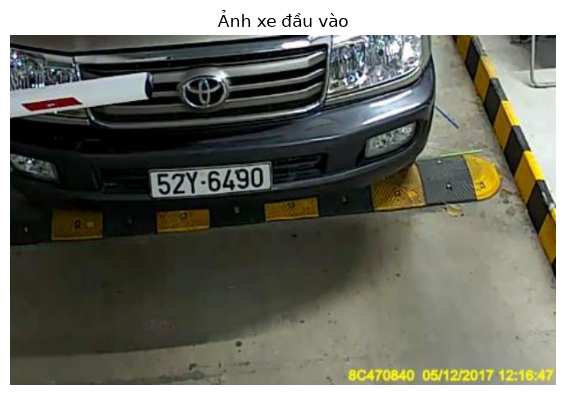

In [3]:
# ===== THAY ĐỔI ĐƯỜNG DẪN ẢNH Ở ĐÂY =====
IMG_PATH = os.path.join('valid', 'images', os.listdir(os.path.join('valid', 'images'))[15])

img_bgr = cv2.imread(IMG_PATH)
assert img_bgr is not None, f'Không đọc được ảnh: {IMG_PATH}'

show('Ảnh xe đầu vào', img_bgr)

## Bước 2 – YOLO: Phát hiện biển số

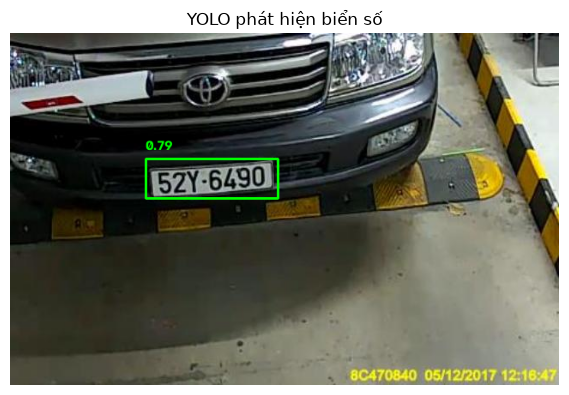

In [4]:
detector = YOLODetector(model_path=YOLO_MODEL, conf_threshold=0.5)
img_drawn = detector.detect_and_draw(img_bgr)

show('YOLO phát hiện biển số', img_drawn)

## Bước 3 – Crop vùng biển số

Confidence: 0.79


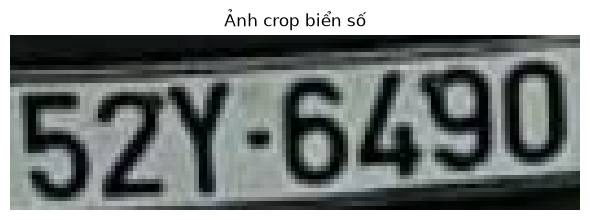

In [5]:
plate_crop, conf = detector.crop_plate(img_bgr)
assert plate_crop is not None, 'YOLO không phát hiện được biển số!'

print(f'Confidence: {conf:.2f}')
show('Ảnh crop biển số', plate_crop)

## Bước 4 – Grayscale: Chuyển sang ảnh xám

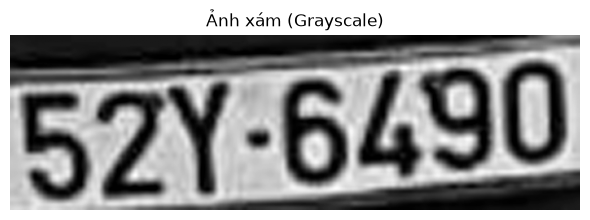

In [6]:
resized, scale = resize_if_small(plate_crop, target_height=180)
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

show('Ảnh xám (Grayscale)', gray)

## Bước 5 – CLAHE: Tăng cường tương phản cục bộ

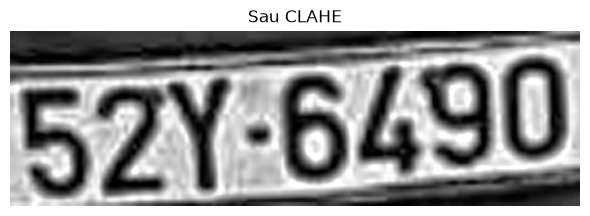

In [7]:
stretched = percentile_stretch(gray, low=2, high=98)
gamma_img, gamma_val = auto_gamma(stretched)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(gamma_img)

show('Sau CLAHE', enhanced)

## Bước 6 – Bilateral Filter + Unsharp Mask: Giảm nhiễu và làm nét

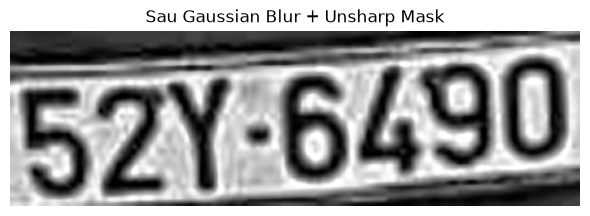

In [18]:
denoised = cv2.bilateralFilter(enhanced, d=5, sigmaColor=45, sigmaSpace=45)
sharp = unsharp_mask(denoised, amount=1.1, sigma=1.0)

show('Sau Gaussian Blur + Unsharp Mask', sharp)

## Bước 7 – Adaptive Threshold: Nhị phân hóa ảnh

Phương pháp được chọn: otsu


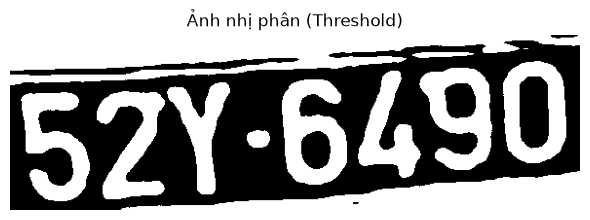

In [19]:
chosen_name, binary, all_candidates = choose_threshold(sharp, method='otsu')

print(f'Phương pháp được chọn: {chosen_name}')
show('Ảnh nhị phân (Threshold)', binary)

## Bước 8 – Morphology: Làm sạch nhiễu

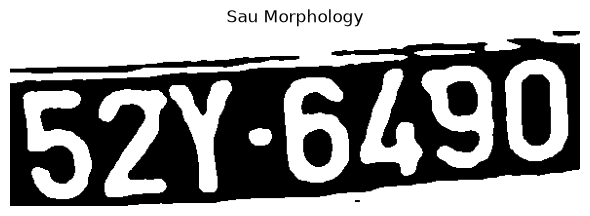

In [20]:
morph = apply_morphology(binary, kernel_size=2)

show('Sau Morphology', morph)

## Bước 9 – Segment: Tách từng ký tự

Số ký tự tách được: 5


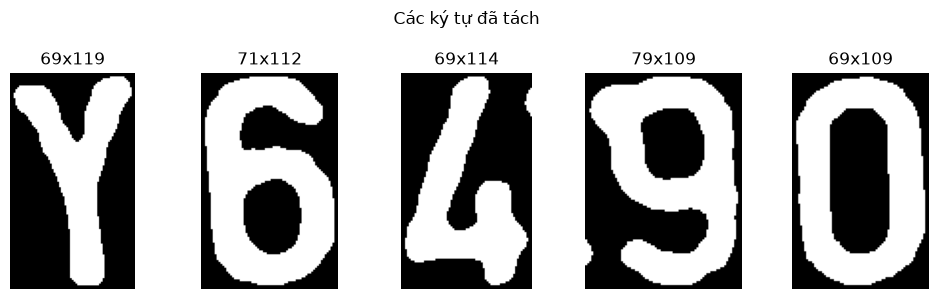

In [21]:
char_data = segment_with_contour(
    morph,
    min_area=80,
    aspect_ratio_range=(1.4, 5.0),
    row_threshold=10,
    pad_char=2,
    margin=5,
)

print(f'Số ký tự tách được: {len(char_data)}')

fig, axes = plt.subplots(1, max(len(char_data), 1), figsize=(2 * max(len(char_data), 1), 3))
if len(char_data) == 0:
    print('Không tách được ký tự nào!')
else:
    if len(char_data) == 1:
        axes = [axes]
    for ax, (char_img, bbox) in zip(axes, char_data):
        ax.imshow(char_img, cmap='gray')
        ax.set_title(f'{bbox[2]}x{bbox[3]}')
        ax.axis('off')
plt.suptitle('Các ký tự đã tách')
plt.tight_layout()
plt.show()

## Bước 10 – HOG: Trích xuất đặc trưng

Số vector HOG: 5
Kích thước mỗi vector: (216,)


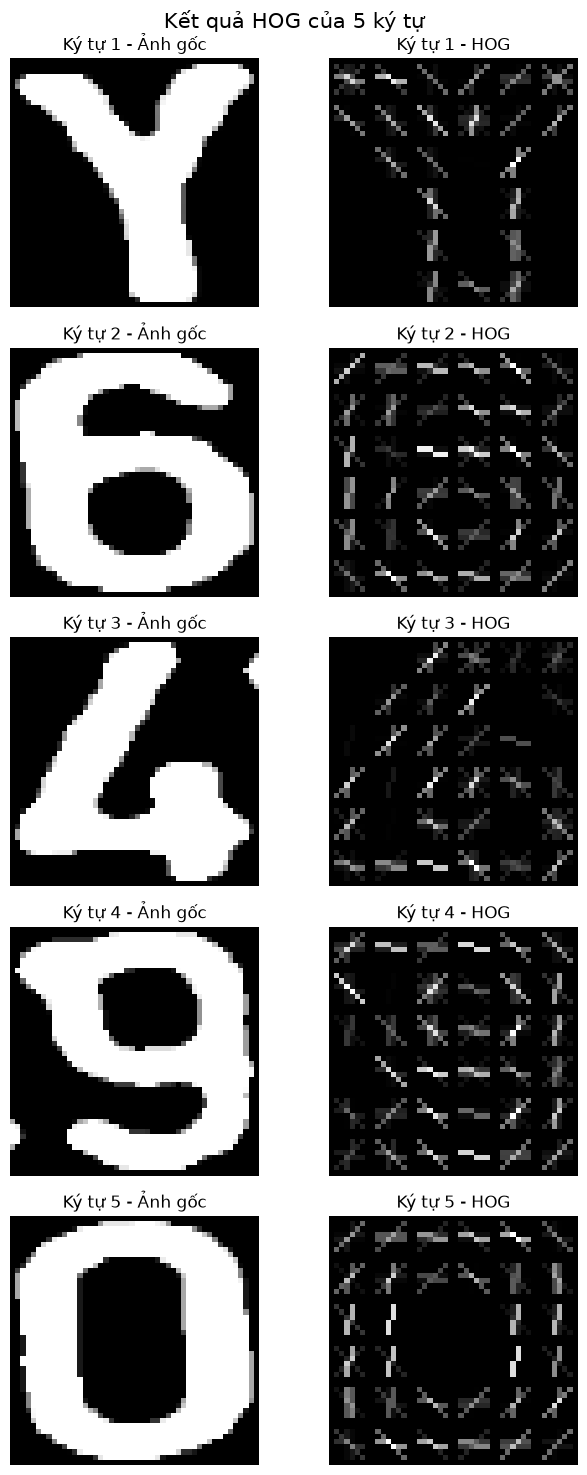

In [ ]:
char_images = [img for img, _ in char_data]
hog_features = [compute_hog_features(img) for img in char_images]

print(f"Số vector HOG: {len(hog_features)}")

if hog_features:
    print(f"Kích thước mỗi vector: {hog_features[0].shape}")

from skimage.feature import hog as sk_hog

if char_images:
    num_chars = len(char_images)

    # Mỗi ký tự gồm 2 ảnh: ảnh gốc và ảnh HOG
    fig, axes = plt.subplots(
        num_chars,
        2,
        figsize=(7, 3 * num_chars)
    )

    # Trường hợp chỉ có 1 ký tự
    if num_chars == 1:
        axes = np.array([axes])

    for i, char_img in enumerate(char_images):
        sample = cv2.resize(char_img, (48, 48))

        _, hog_vis = sk_hog(
            sample,
            orientations=6,
            pixels_per_cell=(8, 8),
            cells_per_block=(1, 1),
            visualize=True,
        )

        # Ảnh ký tự gốc
        axes[i, 0].imshow(sample, cmap="gray")
        axes[i, 0].set_title(f"Ký tự {i + 1} - Ảnh gốc")
        axes[i, 0].axis("off")

        # Ảnh HOG
        axes[i, 1].imshow(hog_vis, cmap="gray")
        axes[i, 1].set_title(f"Ký tự {i + 1} - HOG")
        axes[i, 1].axis("off")

    plt.suptitle(
        f"Kết quả HOG của {num_chars} ký tự",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

else:
    print("Không có ký tự nào để trích xuất HOG.")

## Bước 11 – kNN: Nhận dạng ký tự

In [23]:
knn_model = load_knn_model(KNN_MODEL)
preds = predict_characters(knn_model, char_images)

print(f'Kết quả nhận dạng từng ký tự: {preds}')

Kết quả nhận dạng từng ký tự: ['Y', 'G', '4', '9', 'G']


## Bước 12 – Biển số hoàn chỉnh

Biển số nhận dạng được: YG49G


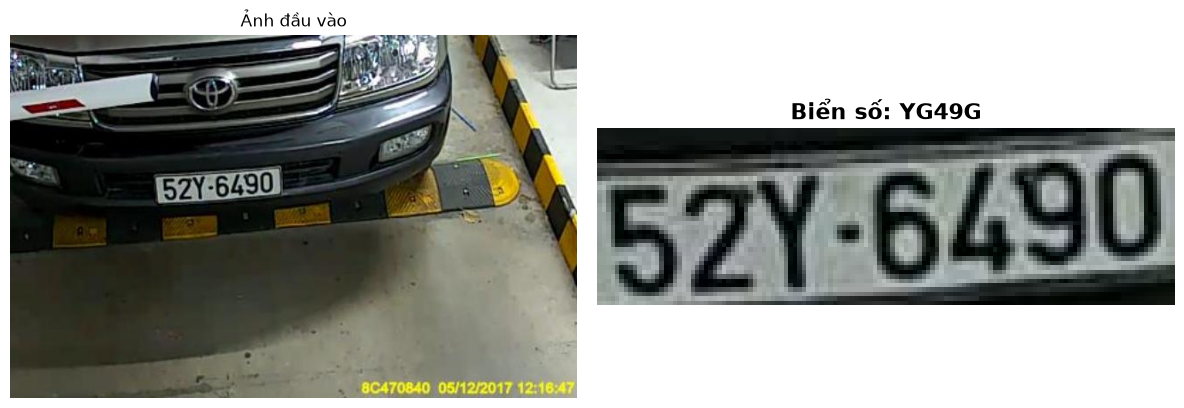

In [24]:
plate_text = ''.join(preds)
print(f'Biển số nhận dạng được: {plate_text}')

# Hiển thị ảnh đầu vào và kết quả cuối cùng
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Ảnh đầu vào')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Biển số: {plate_text}', fontsize=16, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()